In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
from joblib import Parallel, delayed
from StatTools.analysis.dfa import dfa
from scipy import stats
import seaborn as sns
from statsmodels.tsa.stattools import acf

In [ ]:
SIGNALS_DIR = Path(
    "research/kalman_filter/reconstruction_of_long_term_complex_system_dynamics/data/model_signals"
)  # 16 random series were generated independently for each target value H using the python script research/kalman_filter/reconstruction_of_long_term_complex_system_dynamics/gen_filter_save.py
H_LIST: list[float] = [0.7, 0.8, 0.9, 1.0]
NOISE_RATIOS: list[float] = [0.1, 0.3, 0.5, 0.7, 0.9, 2.0, 3.0]
SIGNALS_COUNT: int = 16
ORDERS: list[int] = [2, 4, 8]

## H error

In [3]:
def _compute_h(sig):
    sig = np.array(sig)
    s_vals, f2_vals = dfa(sig, degree=2, processes=1)
    log_s = np.log(s_vals)
    log_f = np.log(np.sqrt(f2_vals))
    return round(stats.linregress(log_s, log_f).slope, 3)


def _compute_one_signal(hi, model_h, signal_idx, ni, nr, method, order):
    filter_h = model_h
    signal_r = np.load(
        SIGNALS_DIR
        / f"recovered_hm{model_h}_{signal_idx}_nr{nr}_{method}_o{order}_hf{filter_h}.npy"
    )
    return hi, model_h, signal_idx, ni, nr, _compute_h(signal_r) - model_h

#### All orders boxplots

In [257]:
# ~50 min
all_records = []

methods_to_test = ["Kasdin"]
orders_to_test = [2, 4, 8]

for method in methods_to_test:
    for order in orders_to_test:
        print(f"Processing: method={method}, order={order}")

        tasks = [
            (hi, model_h, signal_idx, ni, nr, method, order)
            for hi, model_h in enumerate(H_LIST)
            for signal_idx in range(SIGNALS_COUNT)
            for ni, nr in enumerate(NOISE_RATIOS)
        ]

        results = Parallel(n_jobs=-1)(
            delayed(_compute_one_signal)(*t) for t in tqdm(tasks)
        )

        for hi, model_h, signal_idx, ni, nr, error in results:
            all_records.append(
                {
                    "method": method,
                    "order": order,
                    "H_O": model_h,
                    "noise_ratio": nr,
                    "signal_idx": signal_idx,
                    "H_error": error,
                }
            )

full_df = pd.DataFrame(all_records)

Processing: method=Kasdin, order=2


100%|██████████| 448/448 [19:29<00:00,  2.61s/it]


Processing: method=Kasdin, order=4


100%|██████████| 448/448 [18:50<00:00,  2.52s/it]


Processing: method=Kasdin, order=8


100%|██████████| 448/448 [19:13<00:00,  2.57s/it]


In [258]:
full_df["H_r"] = full_df["H_O"] + full_df["H_error"]
full_df.to_csv("full_errors_all_methods_orders.csv", index=False)

In [4]:
# Or use the ready file:
full_df = pd.read_csv("research/data/output/full_errors_all_methods_orders.csv")

In [5]:
full_df.head()

,method,order,H_O,noise_ratio,signal_idx,H_error,H_r
0,Kasdin,2,0.7,0.1,0,-0.124,0.576
1,Kasdin,2,0.7,0.3,0,-0.088,0.612
2,Kasdin,2,0.7,0.5,0,-0.071,0.629
3,Kasdin,2,0.7,0.7,0,-0.062,0.638
4,Kasdin,2,0.7,0.9,0,-0.055,0.645


In [6]:
h_values = sorted(full_df["H_O"].unique())
noise_values = sorted(full_df["noise_ratio"].unique())
orders = sorted(full_df["order"].unique())

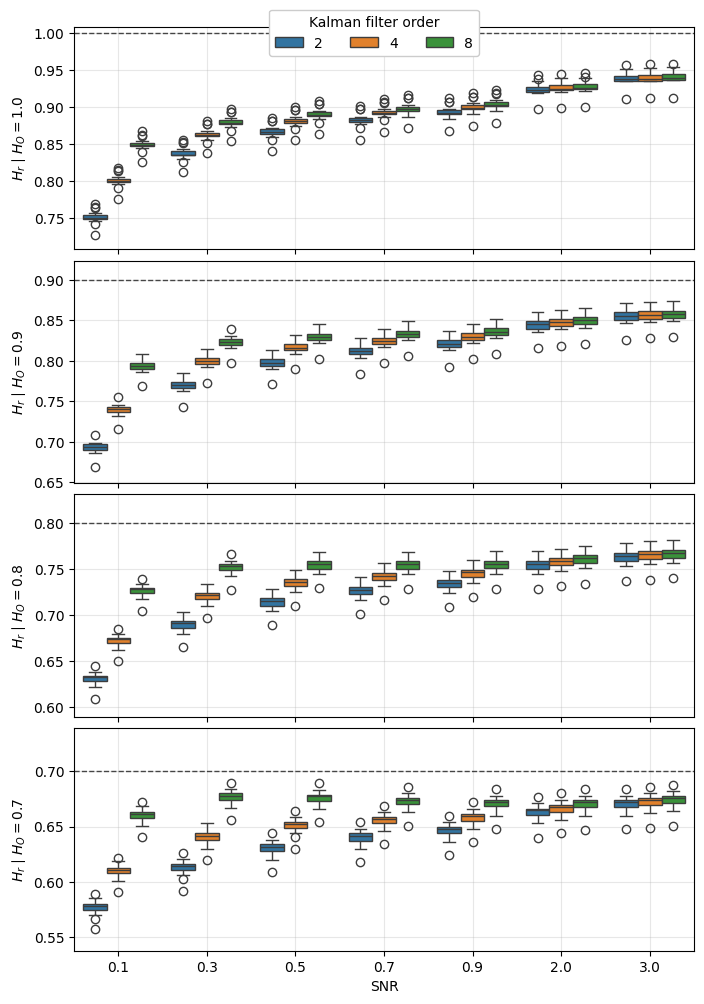

In [7]:
fig, axes = plt.subplots(len(h_values), 1, figsize=(8, 3 * len(h_values)), sharex=True)

if len(h_values) == 1:
    axes = [axes]

handles = None
labels = None

for i, h in enumerate(h_values[-1::-1]):
    ax = axes[i]
    subset = full_df[full_df["H_O"] == h]

    boxplot = sns.boxplot(
        data=subset, x="noise_ratio", y="H_r", hue="order", palette="tab10", ax=ax
    )

    if i == 0:
        handles, labels = ax.get_legend_handles_labels()

    ax.axhline(y=h, color="black", linestyle="--", linewidth=1, alpha=0.7)
    ax.set_ylabel(f"$H_r \\mid H_O = {h}$")
    ax.set_xlabel("SNR" if i == len(h_values) - 1 else "")
    ax.grid(True, alpha=0.3)

    ax.legend_.remove()
    ax.set_ylim(
        full_df[full_df["H_O"] == h]["H_r"].min() - 0.02,
        full_df[full_df["H_O"] == h]["H_r"].max() + 0.05,
    )

fig.legend(
    handles,
    labels,
    title="Kalman filter order",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.9),
    ncol=len(labels),
    framealpha=1.0,
)

plt.subplots_adjust(hspace=0.05)
plt.savefig("research/data/output/h_synth.png", bbox_inches="tight")
plt.savefig("research/data/output/h_synth.svg", bbox_inches="tight")
plt.show()

## ACF

In [12]:
ACF_H_LIST = [0.8, 0.9]
ACF_NOISE_RATIOS = [0.3]
N_LAGS = 300
signal_idx = 5
nr = ACF_NOISE_RATIOS[0]
method = "Kasdin"
lags = np.arange(1, N_LAGS + 2)
lift = 1.3

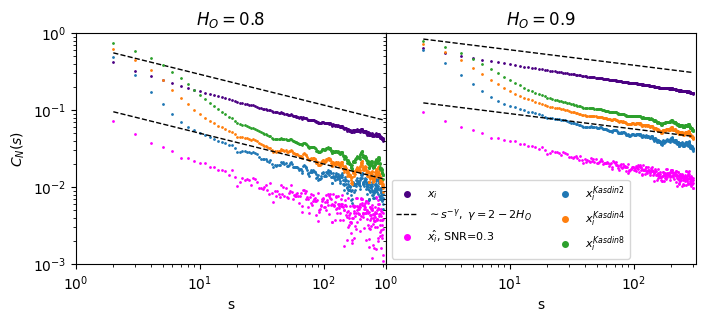

In [13]:
fig, axes = plt.subplots(
    1, len(ACF_H_LIST), figsize=(4 * len(ACF_H_LIST), 3), sharey=True
)

for ax, model_h in zip(axes, ACF_H_LIST):
    gamma = 2 - 2 * model_h
    power_law = lags.astype(float) ** (-gamma)

    # without noise
    signal = np.load(SIGNALS_DIR / f"original_hm{model_h}_{signal_idx}.npy")
    signal_acf = acf(signal, nlags=N_LAGS)

    shift_clean = signal_acf[1] / power_law[1]

    ax.plot(
        lags[1:],
        signal_acf[1:],
        marker=".",
        linestyle="none",
        color="indigo",
        label=f"$x_i$",
        markersize=2,
    )
    ax.plot(
        lags[1:],
        power_law[1:] * shift_clean * lift,
        linestyle="--",
        color="k",
        label=rf"$\sim s^{{-\gamma}},\ \gamma=2-2H_O$",
        linewidth=1,
    )

    # with noise
    noisy_signal = np.load(SIGNALS_DIR / f"noisy_hm{model_h}_{signal_idx}_nr{nr}.npy")
    noisy_acf = acf(noisy_signal, nlags=N_LAGS)

    shift_noisy = noisy_acf[1] / power_law[1]

    ax.plot(
        lags[1:],
        noisy_acf[1:],
        marker=".",
        linestyle="none",
        color="magenta",
        label=f"$\\hat{{x_i}}$, SNR={nr}",
        markersize=2,
    )

    # filtred
    hf = model_h
    for i, order in enumerate(ORDERS):
        filtred_signal = np.load(
            SIGNALS_DIR
            / f"recovered_hm{model_h}_{signal_idx}_nr{nr}_{method}_o{order}_hf{hf}.npy"
        )
        filtred_acf = acf(filtred_signal, nlags=N_LAGS)
        ax.plot(
            lags[1:],
            filtred_acf[1:],
            marker=".",
            linestyle="none",
            label=f"$x_i^{{{method}{order}}}$",
            color=sns.color_palette("tab10", len(ORDERS))[i],
            markersize=2,
        )

    ax.plot(
        lags[1:],
        power_law[1:] * shift_noisy * lift,
        linestyle="--",
        color="k",
        linewidth=1,
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(10**0, 10 ** (2.5))
    ax.set_ylim(10 ** (-3), 10**0)
    ax.set_xlabel("s")
    ax.set_title(f"$H_O={model_h:.1f}$")

axes[1].legend(ncols=2, fontsize=8, markerscale=4)

axes[0].set_ylabel("$C_N(s)$")
plt.subplots_adjust(wspace=0)
plt.savefig("research/data/output/acf_filtred.png", bbox_inches="tight", pad_inches=0.1)
plt.savefig("research/data/output/acf_filtred.svg", bbox_inches="tight", pad_inches=0.1)
plt.show()